# Exploratory Data Analysis (EDA)

## Objetivo

En los sistemas Retrieval-Augmented Generation (RAG), la fase de Exploratory Data Analysis (EDA) tiene como objetivo comprender la estructura, calidad y contenido de los documentos que servirán como base de conocimiento del chatbot.

A diferencia de los proyectos tradicionales de Machine Learning, donde el EDA se centra en analizar variables y distribuciones para construir modelos predictivos, en un sistema RAG el análisis se enfoca en:

- Comprender el tipo de documentos disponibles
- Evaluar su calidad textual
- Identificar ruido o información irrelevante
- Analizar la longitud y estructura del contenido
- Determinar la mejor estrategia de chunking para embeddings
- Detectar posibles problemas de extracción de texto

## Objetivos específicos

Durante esta fase se buscará:

1. Analizar la cantidad y tipos de documentos disponibles.
2. Evaluar el tamaño y longitud del contenido textual.
3. Detectar posibles errores de extracción (texto vacío, caracteres extraños).
4. Analizar la distribución de longitud de documentos.
5. Comprender la temática general del corpus.

Este análisis permitirá preparar correctamente los datos antes de la etapa de **preprocesamiento y generación de embeddings**.

In [9]:
# =============================================
# Configuración inicial del entorno — EDA RAG
# =============================================

# Librerías principales
import os
from pathlib import Path
import random
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display, Markdown

# Extracción y limpieza de PDFs
from pypdf import PdfReader
import pdfplumber
import re
import unicodedata

# Procesamiento de texto
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Utilidades del sistema
import warnings
warnings.filterwarnings('ignore')

# Configuración gráfica
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lugod\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
import os
import pandas as pd
from pathlib import Path

In [4]:
RAW_DIR = "../data/raw"

files = os.listdir(RAW_DIR)

print("Total de documentos:", len(files))
files

Total de documentos: 15


['bond_fund_risk_monetary_policy.pdf',
 'eurosistemas.pdf',
 'eurosystem_monetary_framework.pdf',
 'evolucion_economica_financiera_monetaria.pdf',
 'glosario_economico.pdf',
 'implications_for_financial_stability.pdf',
 'macroeconomia_ingles.pdf',
 'money_demand_non_financial_corporationpdf.pdf',
 'reporte_anual_resumen_2023_ingles.pdf',
 'reporte_anual_resumen_2024_ingles.pdf',
 'respuesta_politica_pandemia.pdf',
 'stabalecoins_monetary_policy.pdf',
 'the_art_of_taxation.pdf',
 'the_labor_market_euro.pdf',
 'understanding_inflation.pdf']

In [5]:
data = []

for file in files:
    path = os.path.join(RAW_DIR, file)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    
    data.append({
        "document": file,
        "size_mb": round(size_mb, 2)
    })

df_files = pd.DataFrame(data)

df_files

,document,size_mb
0,bond_fund_risk_monetary_policy.pdf,2.92
1,eurosistemas.pdf,1.61
2,eurosystem_monetary_framework.pdf,0.32
3,evolucion_economica_financiera_monetaria.pdf,1.21
4,glosario_economico.pdf,0.13
5,implications_for_financial_stability.pdf,1.37
6,macroeconomia_ingles.pdf,0.85
7,money_demand_non_financial_corporationpdf.pdf,4.24
8,reporte_anual_resumen_2023_ingles.pdf,0.43
9,reporte_anual_resumen_2024_ingles.pdf,0.46


In [6]:
df_files.describe()

,size_mb
count,15.000000
mean,1.553333
std,1.359473
min,0.090000
25%,0.445000
50%,1.210000
75%,2.615000
max,4.240000


In [7]:
from pypdf import PdfReader

# Carpeta con los PDFs
RAW_DIR = "../data/raw"

# Lista para guardar resultados
eda_results = []

# Recorrer todos los PDFs
for filename in os.listdir(RAW_DIR):
    if filename.lower().endswith(".pdf"):
        path = os.path.join(RAW_DIR, filename)
        result = {"document": filename, "status": "", "text_length": 0}
        
        try:
            reader = PdfReader(path)
            text = ""
            
            # Extraer texto de todas las páginas
            for page in reader.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text
            
            # Guardar longitud del texto
            result["text_length"] = len(text.strip())
            
            # Clasificar PDF según cantidad de texto
            if len(text.strip()) > 50:
                result["status"] = "OK"
            else:
                result["status"] = "WARNING: poco texto"
        
        except Exception as e:
            result["status"] = f"ERROR: {e}"
        
        eda_results.append(result)

# Convertir a DataFrame
df_eda = pd.DataFrame(eda_results)

# Mostrar resultados
df_eda

,document,status,text_length
0,bond_fund_risk_monetary_policy.pdf,OK,112413
1,eurosistemas.pdf,OK,70319
2,eurosystem_monetary_framework.pdf,OK,81275
3,evolucion_economica_financiera_monetaria.pdf,OK,102446
4,glosario_economico.pdf,OK,6794
5,implications_for_financial_stability.pdf,OK,136762
6,macroeconomia_ingles.pdf,OK,89951
7,money_demand_non_financial_corporationpdf.pdf,OK,83132
8,reporte_anual_resumen_2023_ingles.pdf,OK,129882
9,reporte_anual_resumen_2024_ingles.pdf,OK,140277


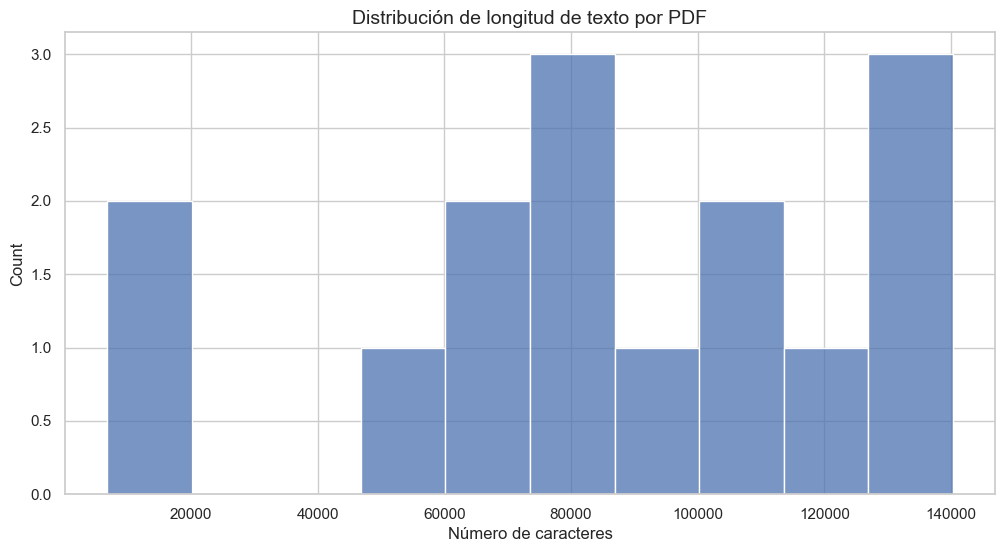

In [10]:
sns.histplot(df_eda['text_length'], bins=10)
plt.title("Distribución de longitud de texto por PDF")
plt.xlabel("Número de caracteres")
plt.show()

In [11]:
# Estadísticas del texto de cada PDF
df_eda['text_length_k'] = df_eda['text_length'] / 1000  # en miles de caracteres

display(df_eda[['document', 'text_length', 'text_length_k']])

# Estadísticas descriptivas
df_eda['text_length'].describe()

,document,text_length,text_length_k
0,bond_fund_risk_monetary_policy.pdf,112413,112.413
1,eurosistemas.pdf,70319,70.319
2,eurosystem_monetary_framework.pdf,81275,81.275
3,evolucion_economica_financiera_monetaria.pdf,102446,102.446
4,glosario_economico.pdf,6794,6.794
5,implications_for_financial_stability.pdf,136762,136.762
6,macroeconomia_ingles.pdf,89951,89.951
7,money_demand_non_financial_corporationpdf.pdf,83132,83.132
8,reporte_anual_resumen_2023_ingles.pdf,129882,129.882
9,reporte_anual_resumen_2024_ingles.pdf,140277,140.277


count        15.000000
mean      86212.133333
std       40844.235772
min        6794.000000
25%       70993.500000
50%       83132.000000
75%      118195.500000
max      140277.000000
Name: text_length, dtype: float64

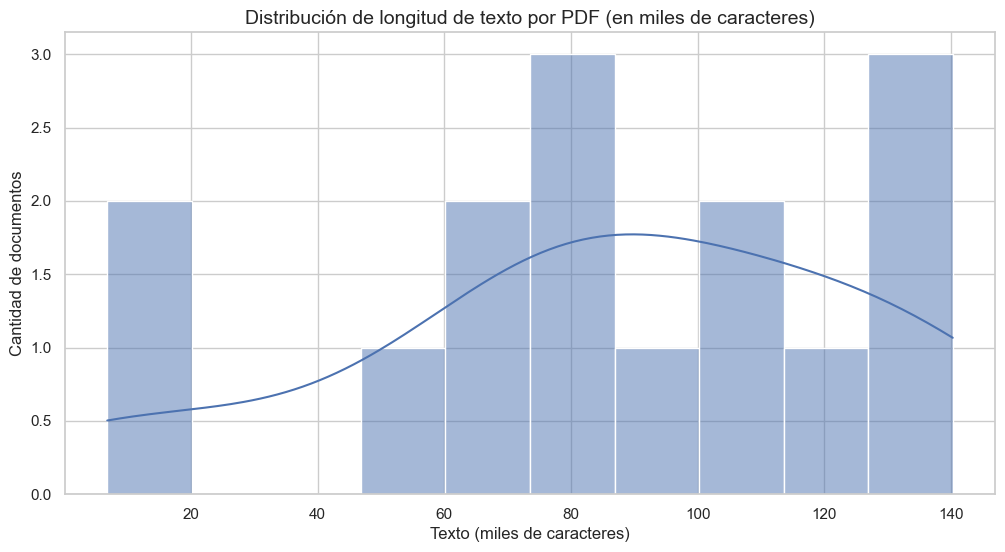

In [12]:
plt.figure(figsize=(12,6))
sns.histplot(df_eda['text_length_k'], bins=10, kde=True)
plt.title("Distribución de longitud de texto por PDF (en miles de caracteres)")
plt.xlabel("Texto (miles de caracteres)")
plt.ylabel("Cantidad de documentos")
plt.show()